# Release Area Analysis - Interactive Notebook

This notebook performs terrain criteria and retrogression analysis to estimate potential landslide release areas.

**Features:**
- Step-by-step execution
- Interactive visualizations
- Data inspection and statistics
- Parameter customization

---

## 1. Setup and Imports

In [48]:
import sys
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import rasterio
from rasterio.plot import show

# Add the src directory to the path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from losneomrade import terrain_criteria, retrogression
from losneomrade.terrain_criteria import generate_source_points

# Display settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("✓ Imports complete")

✓ Imports complete


In [ ]:
# Install required package for progress bars in Jupyter
import sys
!{sys.executable} -m pip install ipywidgets --quiet

## 2. Configuration

**Adjust these parameters as needed:**

In [49]:
# ============================================================================
# INPUT FILES
# ============================================================================
STREAM_FILE = "../data/streams_as_source.geojson"
CUSTOM_DEM = "../data/dem_byneset_5m.tif"

# ============================================================================
# ANALYSIS PARAMETERS (NVE Standard)
# ============================================================================
SOURCE_DEPTH = 0.0      # Depth of source below surface (meters)
MIN_HEIGHT = 5.0        # Minimum height for calculations (meters)
MIN_SLOPE = 1/15        # Slope criterion (1:15 ratio per NVE)
MIN_LENGTH = 75.0       # Minimum length from source (meters)
CLIP_TO_MSML = False    # Clip to marine clay areas

# ============================================================================
# PROCESSING PARAMETERS
# ============================================================================
BUFFER_DISTANCE = 200   # Buffer around streams (meters) - REDUCED for memory
POINTS_PER_METER = 1/50 # Source point spacing (1/20 = every 20m) - REDUCED for memory

# ============================================================================
# OUTPUT
# ============================================================================
OUTPUT_DIR = "../output"

# Print configuration
print("Configuration:")
print(f"  Stream file: {STREAM_FILE}")
print(f"  DEM file: {CUSTOM_DEM}")
print(f"  Source depth: {SOURCE_DEPTH}m")
print(f"  Min height: {MIN_HEIGHT}m")
print(f"  Min slope: 1:{int(1/MIN_SLOPE)} ({MIN_SLOPE:.4f})")
print(f"  Min length: {MIN_LENGTH}m")
print(f"  Buffer: {BUFFER_DISTANCE}m")
print(f"  Point spacing: {1/POINTS_PER_METER:.1f}m")
print(f"\n⚠️  Memory optimization enabled:")
print(f"  - Reduced buffer distance to {BUFFER_DISTANCE}m")
print(f"  - Increased point spacing to {1/POINTS_PER_METER:.1f}m")

Configuration:
  Stream file: ../data/streams_as_source.geojson
  DEM file: ../data/dem_byneset_5m.tif
  Source depth: 0.0m
  Min height: 5.0m
  Min slope: 1:15 (0.0667)
  Min length: 75.0m
  Buffer: 200m
  Point spacing: 50.0m

⚠️  Memory optimization enabled:
  - Reduced buffer distance to 200m
  - Increased point spacing to 50.0m


## 3. Load and Inspect Data

In [50]:
# Load streams
print("Loading stream data...")
streams = gpd.read_file(STREAM_FILE)

print(f"\n✓ Loaded {len(streams)} stream features")
print(f"  CRS: {streams.crs}")
print(f"  Geometry types: {streams.geom_type.unique().tolist()}")
print(f"  Total stream length: {streams.geometry.length.sum()/1000:.2f} km")

# Display first few rows
print("\nFirst 5 stream features:")
streams.head()

Loading stream data...

✓ Loaded 1692 stream features
  CRS: EPSG:25833
  Geometry types: ['MultiLineString']
  Total stream length: 101.71 km

First 5 stream features:

✓ Loaded 1692 stream features
  CRS: EPSG:25833
  Geometry types: ['MultiLineString']
  Total stream length: 101.71 km

First 5 stream features:


,fid,objtype,lokalid,medium,vannbredde,vannsperretype,arealRegineEnhet_km2,elveordenStrahler,catch_area,water_depth,gradient,aggressive,aggressiveness,id,geometry
0,1,Kystkontur,db9c9801-418f-41c4-9c46-f6d757bc8e84,T,NaN,None,None,None,0.013276,1.0,0.0,0.0,0.0,1,"MULTILINESTRING ((256773.865 7033724.535, 2567..."
1,2,Kystkontur,cf890cc7-a23b-4ba1-a1c8-1b58a2c004e6,T,NaN,None,None,None,0.004518,1.0,0.0,0.0,0.0,2,"MULTILINESTRING ((256233.028 7034128.14, 25623..."
2,3,Kystkontur,feade9c4-3f47-42d9-a165-944ad1d9cc6a,T,NaN,None,None,None,0.001561,7.5,0.0,0.0,0.0,3,"MULTILINESTRING ((256046.756 7034197.171, 2560..."
3,4,Kystkontur,cf890cc7-a23b-4ba1-a1c8-1b58a2c004e6,T,NaN,None,None,None,0.003235,1.0,0.0,0.0,0.0,4,"MULTILINESTRING ((256174.309 7034198.527, 2561..."
4,5,Kystkontur,feade9c4-3f47-42d9-a165-944ad1d9cc6a,T,NaN,None,None,None,9.927003,7.5,0.0,0.0,0.0,5,"MULTILINESTRING ((256028.726 7034145.225, 2560..."


In [51]:
# Verify DEM
dem_path = Path(CUSTOM_DEM)
if not dem_path.exists():
    raise FileNotFoundError(f"DEM file not found: {CUSTOM_DEM}")

# Read DEM metadata
with rasterio.open(CUSTOM_DEM) as src:
    dem_bounds = src.bounds
    dem_crs = src.crs
    dem_res = src.res
    dem_shape = src.shape
    dem_array = src.read(1)

print(f"✓ DEM file found: {CUSTOM_DEM}")
print(f"  File size: {dem_path.stat().st_size / (1024*1024):.2f} MB")
print(f"  CRS: {dem_crs}")
print(f"  Resolution: {dem_res[0]}m x {dem_res[1]}m")
print(f"  Dimensions: {dem_shape[1]} x {dem_shape[0]} pixels")
print(f"  Elevation range: {dem_array[dem_array > -9999].min():.1f}m to {dem_array[dem_array > -9999].max():.1f}m")

✓ DEM file found: ../data/dem_byneset_5m.tif
  File size: 11.53 MB
  CRS: EPSG:25833
  Resolution: 5.003190589946987m x 5.0031905899469855m
  Dimensions: 1462 x 2066 pixels
  Elevation range: -0.0m to 565.4m


## 4. Visualize Input Data

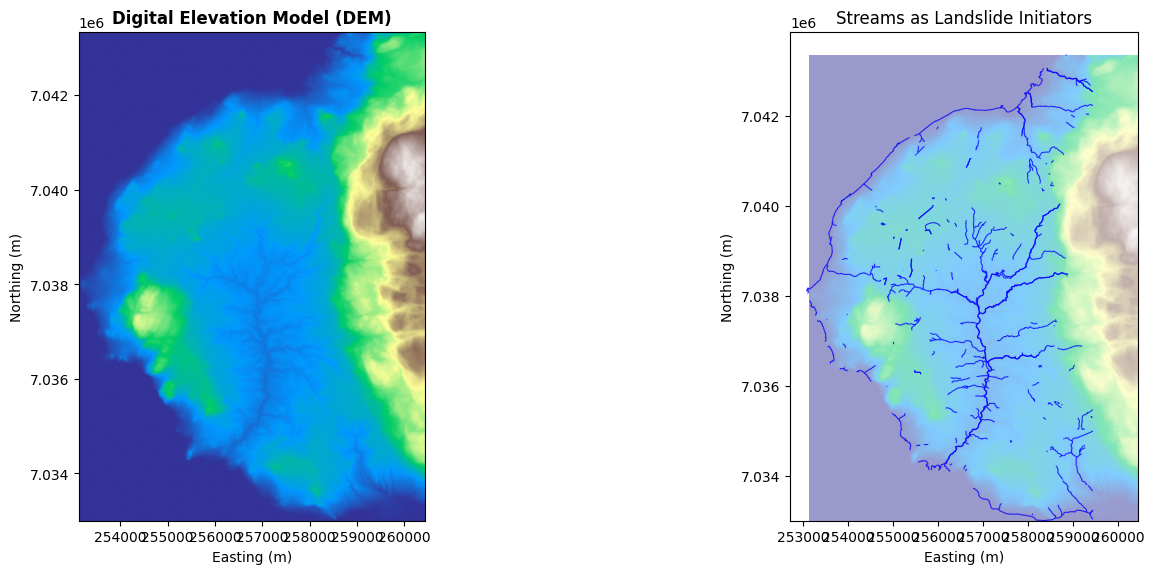

✓ Input data visualized


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DEM
ax1 = axes[0]
with rasterio.open(CUSTOM_DEM) as src:
    show(src, ax=ax1, cmap='terrain', title='Digital Elevation Model (DEM)')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')

# Plot 2: Streams on DEM
ax2 = axes[1]
with rasterio.open(CUSTOM_DEM) as src:
    show(src, ax=ax2, cmap='terrain', alpha=0.5)
streams.plot(ax=ax2, color='blue', linewidth=0.8, alpha=0.8)
ax2.set_title('Streams as Landslide Initiators')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')

plt.tight_layout()
plt.show()

print(f"✓ Input data visualized")

## 5. Calculate Analysis Bounds

In [53]:
# Calculate bounds with buffer
bounds_array = streams.total_bounds  # [minx, miny, maxx, maxy]
bounds = (
    bounds_array[0] - BUFFER_DISTANCE,  # xmin
    bounds_array[2] + BUFFER_DISTANCE,  # xmax
    bounds_array[1] - BUFFER_DISTANCE,  # ymin
    bounds_array[3] + BUFFER_DISTANCE   # ymax
)

print(f"Analysis bounds (with {BUFFER_DISTANCE}m buffer):")
print(f"  X: {bounds[0]:.2f} to {bounds[1]:.2f} ({bounds[1]-bounds[0]:.2f}m width)")
print(f"  Y: {bounds[2]:.2f} to {bounds[3]:.2f} ({bounds[3]-bounds[2]:.2f}m height)")
print(f"  Area: {(bounds[1]-bounds[0]) * (bounds[3]-bounds[2]) / 1e6:.2f} km²")

Analysis bounds (with 200m buffer):
  X: 252877.52 to 259635.00 (6757.48m width)
  Y: 7032806.36 to 7043556.52 (10750.16m height)
  Area: 72.64 km²


## 6. Generate Source Points

Convert stream lines into discrete source points for analysis:

In [54]:
print("Generating source points from streams...")
print(f"  Point spacing: {1/POINTS_PER_METER:.1f}m")

source_points = generate_source_points(streams, distance_chainage=1/POINTS_PER_METER)

print(f"\n✓ Generated {len(source_points):,} source points")
print(f"  Total stream length: {streams.geometry.length.sum():.2f}m")
print(f"  Points per meter: {len(source_points) / streams.geometry.length.sum():.3f}")

# Display first few points
print("\nFirst 5 source points (x, y):")
print(source_points[:5])

Generating source points from streams...
  Point spacing: 50.0m

✓ Generated 8,460 source points
  Total stream length: 101705.13m
  Points per meter: 0.083

First 5 source points (x, y):
[[ 256773.86462259 7033724.53476735]
 [ 256789.72021771 7033714.9164014 ]
 [ 256807.27679936 7033708.67711947]
 [ 256824.21700998 7033701.11656381]
 [ 256839.44321122 7033690.34098904]]

✓ Generated 8,460 source points
  Total stream length: 101705.13m
  Points per meter: 0.083

First 5 source points (x, y):
[[ 256773.86462259 7033724.53476735]
 [ 256789.72021771 7033714.9164014 ]
 [ 256807.27679936 7033708.67711947]
 [ 256824.21700998 7033701.11656381]
 [ 256839.44321122 7033690.34098904]]


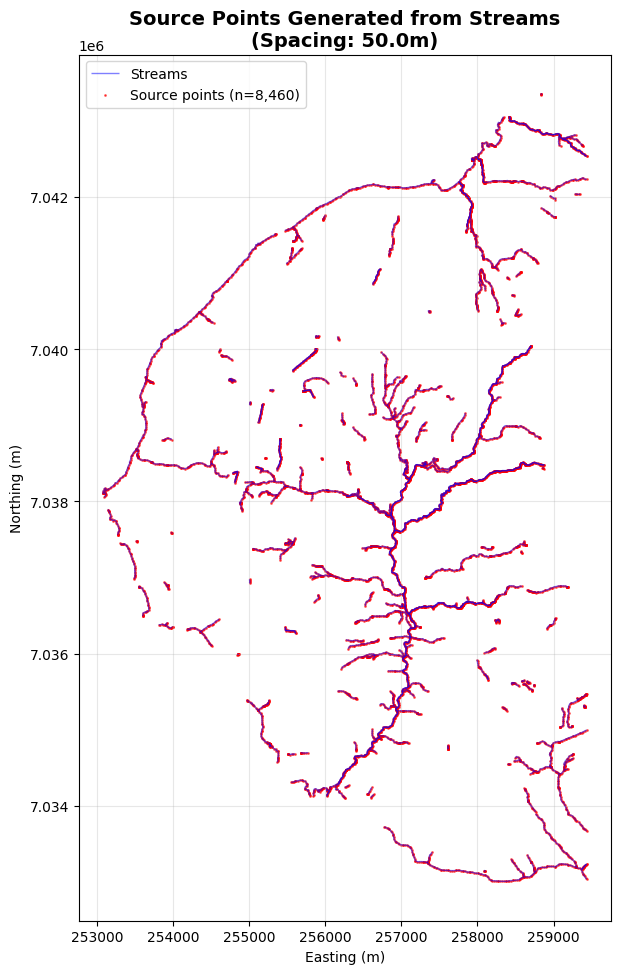

In [55]:
# Visualize source points
fig, ax = plt.subplots(figsize=(12, 10))

streams.plot(ax=ax, color='blue', linewidth=1, alpha=0.5, label='Streams')
ax.scatter(source_points[:, 0], source_points[:, 1], 
           c='red', s=1, alpha=0.6, label=f'Source points (n={len(source_points):,})')

ax.set_title(f'Source Points Generated from Streams\n(Spacing: {1/POINTS_PER_METER:.1f}m)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Terrain Criteria Analysis

Identify areas where slope from source points exceeds 1:15:

### 💡 Memory Optimization

**Note:** The terrain criteria analysis computes slopes from EVERY source point to EVERY DEM pixel. With 11,809 points and a large DEM, this requires substantial memory.

**Options to reduce memory usage:**
1. Increase `POINTS_PER_METER` (fewer points, less detail)
2. Reduce `BUFFER_DISTANCE` (smaller analysis area)
3. Process in smaller chunks (modify code)

If you encounter memory errors, go back to Section 2 and adjust:
- `POINTS_PER_METER = 1/20` (one point every 20m instead of 10m)
- `BUFFER_DISTANCE = 200` (reduce from 300m)

In [56]:
# OPTIONAL: Reduce source points if memory is limited
# Uncomment and run this cell if you get memory errors

# Option 1: Simple downsampling - keep every Nth point
DOWNSAMPLE_FACTOR = 5  # Keep every 2nd point (reduces by 50%)
source_points_reduced = source_points[::DOWNSAMPLE_FACTOR]

# Option 2: Spatial thinning - ensure minimum distance between points
# from scipy.spatial import cKDTree
# MIN_DISTANCE = 20  # Minimum 20m between points
# selected_indices = [0]
# tree = cKDTree(source_points[:, :2])
# for i in range(1, len(source_points)):
#     distances, _ = tree.query(source_points[i, :2], k=len(selected_indices)+1)
#     if np.min(distances[1:]) > MIN_DISTANCE:
#         selected_indices.append(i)
# source_points_reduced = source_points[selected_indices]

# Use reduced points for analysis
print(f"Reduced from {len(source_points):,} to {len(source_points_reduced):,} points")
source_points = source_points_reduced

Reduced from 8,460 to 1,692 points


In [57]:
print("Running terrain criteria analysis...")
print("This may take a few minutes...\n")

tc_result = terrain_criteria.run_terrain_criteria(
    bounds=bounds,
    source=source_points,
    source_depth=SOURCE_DEPTH,
    clip_to_msml=CLIP_TO_MSML,
    h_min=MIN_HEIGHT,
    reclassify_results=True,
    custom_raster=CUSTOM_DEM
)

print(f"\n✓ Terrain criteria analysis completed!")
print(f"  Polygons: {len(tc_result)}")
print(f"  Total area: {tc_result.geometry.area.sum():.2f} m²")
print(f"  Total area: {tc_result.geometry.area.sum()/10000:.2f} hectares")
print(f"  Avg polygon area: {tc_result.geometry.area.mean():.2f} m²")
print(f"  Largest polygon: {tc_result.geometry.area.max():.2f} m²")

Running terrain criteria analysis...
This may take a few minutes...


✓ Terrain criteria analysis completed!
  Polygons: 4390
  Total area: 51389472.37 m²
  Total area: 5138.95 hectares
  Avg polygon area: 11706.03 m²
  Largest polygon: 28460262.27 m²

✓ Terrain criteria analysis completed!
  Polygons: 4390
  Total area: 51389472.37 m²
  Total area: 5138.95 hectares
  Avg polygon area: 11706.03 m²
  Largest polygon: 28460262.27 m²


In [58]:
# Display terrain criteria results
print("Terrain Criteria Results (first 10 polygons):")
tc_result.head(10)

Terrain Criteria Results (first 10 polygons):


,geometry,slope
0,"POLYGON ((259852.964 7043338.766, 259852.964 7...",1
2,"POLYGON ((258982.409 7043338.766, 258982.409 7...",1
3,"POLYGON ((258437.061 7043178.664, 258437.061 7...",1
4,"POLYGON ((258367.016 7043133.635, 258367.016 7...",1
5,"POLYGON ((258377.022 7043133.635, 258377.022 7...",1
6,"POLYGON ((258372.019 7043133.635, 258372.019 7...",2
7,"POLYGON ((258707.233 7043338.766, 258707.233 7...",1
8,"POLYGON ((258412.045 7043098.613, 258412.045 7...",1
9,"POLYGON ((258417.048 7043093.61, 258417.048 70...",1
10,"POLYGON ((258392.032 7043053.584, 258392.032 7...",1


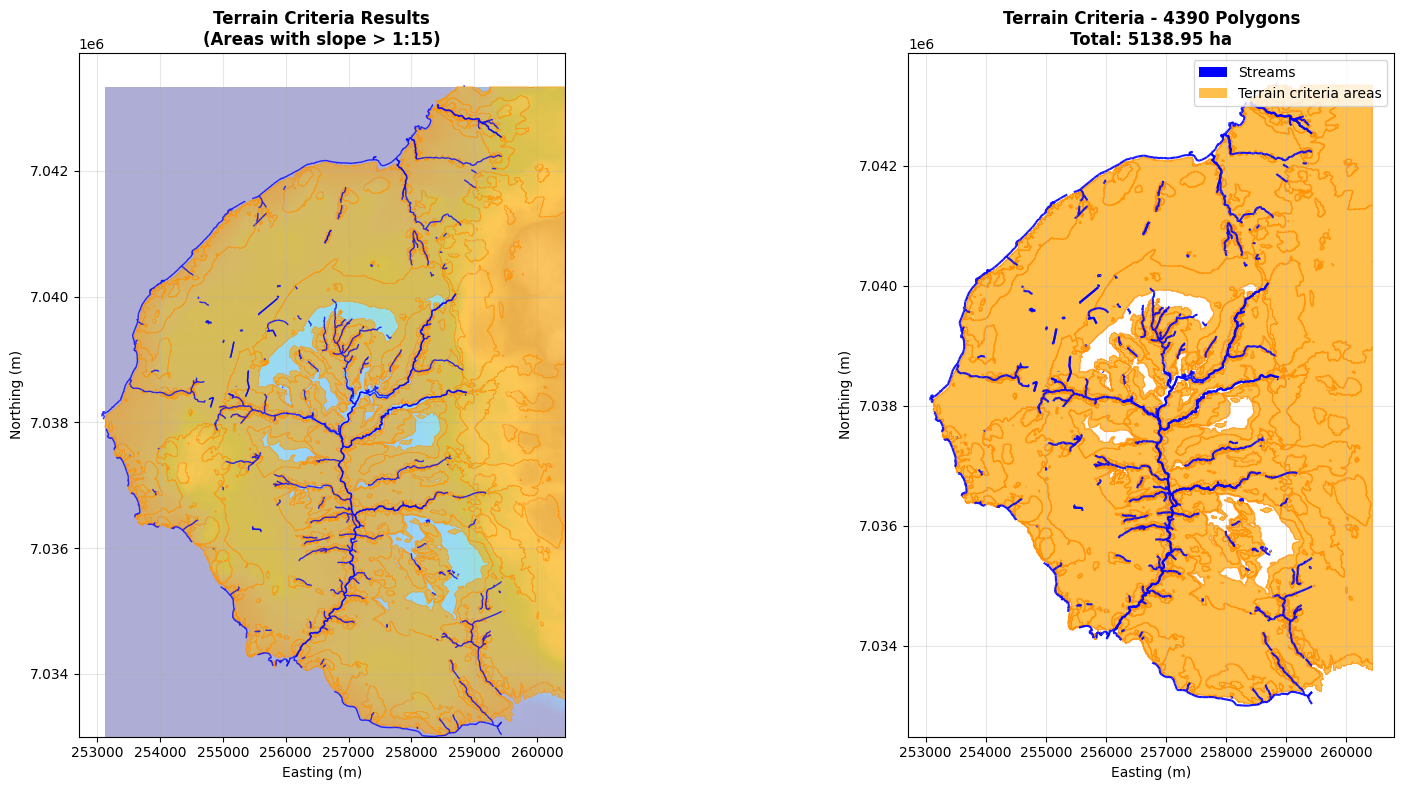

In [59]:
# Visualize terrain criteria results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Terrain criteria on DEM
ax1 = axes[0]
with rasterio.open(CUSTOM_DEM) as src:
    show(src, ax=ax1, cmap='terrain', alpha=0.4)
tc_result.plot(ax=ax1, color='orange', alpha=0.6, edgecolor='darkorange', linewidth=0.5)
streams.plot(ax=ax1, color='blue', linewidth=1, alpha=0.8)
ax1.set_title('Terrain Criteria Results\n(Areas with slope > 1:15)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.grid(True, alpha=0.3)

# Plot 2: Close-up without DEM
ax2 = axes[1]
tc_result.plot(ax=ax2, color='orange', alpha=0.7, edgecolor='darkorange', linewidth=0.8)
streams.plot(ax=ax2, color='blue', linewidth=1.5, alpha=0.9)
ax2.set_title(f'Terrain Criteria - {len(tc_result)} Polygons\n'
              f'Total: {tc_result.geometry.area.sum()/10000:.2f} ha', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='blue', label='Streams'),
    Patch(facecolor='orange', alpha=0.7, label='Terrain criteria areas')
]
ax2.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

## 8. Area Statistics

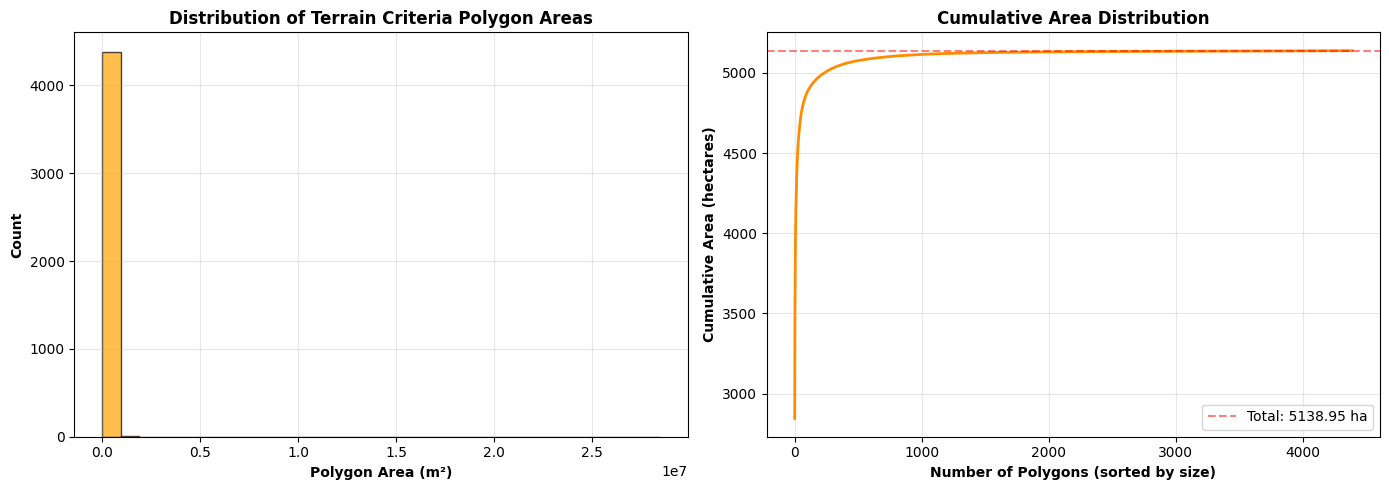

Statistics:
  Mean area: 11706.03 m² (1.1706 ha)
  Median area: 50.06 m²
  Std deviation: 437718.68 m²
  Largest 10% contains: 5067.23 ha (98.6% of total)


In [60]:
# Calculate statistics
tc_areas = tc_result.geometry.area

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of polygon areas
ax1 = axes[0]
ax1.hist(tc_areas, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Polygon Area (m²)', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Distribution of Terrain Criteria Polygon Areas', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cumulative area
ax2 = axes[1]
sorted_areas = np.sort(tc_areas)[::-1]
cumsum_areas = np.cumsum(sorted_areas) / 10000  # Convert to hectares
ax2.plot(range(1, len(sorted_areas)+1), cumsum_areas, color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Polygons (sorted by size)', fontweight='bold')
ax2.set_ylabel('Cumulative Area (hectares)', fontweight='bold')
ax2.set_title('Cumulative Area Distribution', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=cumsum_areas[-1], color='red', linestyle='--', alpha=0.5, 
            label=f'Total: {cumsum_areas[-1]:.2f} ha')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Statistics:")
print(f"  Mean area: {tc_areas.mean():.2f} m² ({tc_areas.mean()/10000:.4f} ha)")
print(f"  Median area: {tc_areas.median():.2f} m²")
print(f"  Std deviation: {tc_areas.std():.2f} m²")
print(f"  Largest 10% contains: {cumsum_areas[int(len(tc_result)*0.1)]:.2f} ha ({cumsum_areas[int(len(tc_result)*0.1)]/cumsum_areas[-1]*100:.1f}% of total)")

## 9. Save Terrain Criteria Results

In [61]:
# Create output directory
Path(OUTPUT_DIR).mkdir(exist_ok=True)

# Save results
tc_output = f"{OUTPUT_DIR}/terrain_criteria_custom_dem.geojson"
tc_result.to_file(tc_output, driver='GeoJSON')

print(f"✓ Terrain criteria results saved to: {tc_output}")

✓ Terrain criteria results saved to: ../output/terrain_criteria_custom_dem.geojson


## 10. Retrogression Analysis (Independent Method)

**Retrogression is an independent analysis method** that uses step-wise upslope propagation.

Two approaches:
1. **Independent**: Start from source points (buffered to create initial release zone)
2. **Sequential**: Start from terrain criteria results (shown in Section 10B)

---

### 10A. Retrogression from Source Points (Independent)

In [62]:
# Create initial release zones from source points
# Buffer source points to create small polygons as starting zones
print("Creating initial release zones from source points...")

from shapely.geometry import Point
import geopandas as gpd

# Create point geometries
point_geometries = [Point(x, y) for x, y in source_points[:, :2]]
points_gdf = gpd.GeoDataFrame(geometry=point_geometries, crs='EPSG:25833')

# Buffer points to create initial release zones (small circles)
INITIAL_BUFFER = 10  # 10m radius around each source point
initial_release = points_gdf.buffer(INITIAL_BUFFER)
initial_release_gdf = gpd.GeoDataFrame(geometry=initial_release, crs='EPSG:25833')

# Dissolve overlapping buffers into single features
initial_release_dissolved = initial_release_gdf.dissolve()

print(f"  - Created {len(initial_release_dissolved)} initial release zones")
print(f"  - Total initial area: {initial_release_dissolved.geometry.area.sum():.2f} m²")
print(f"  - Buffer radius: {INITIAL_BUFFER}m")

Creating initial release zones from source points...
  - Created 1 initial release zones
  - Total initial area: 429398.81 m²
  - Buffer radius: 10m
  - Created 1 initial release zones
  - Total initial area: 429398.81 m²
  - Buffer radius: 10m


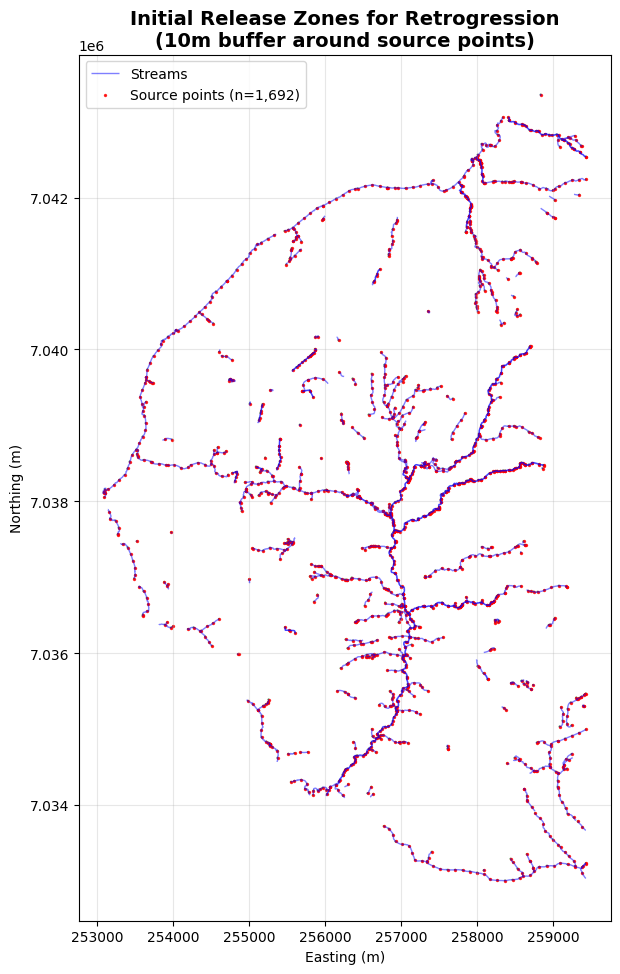

In [63]:
# Visualize initial release zones
fig, ax = plt.subplots(figsize=(12, 10))

streams.plot(ax=ax, color='blue', linewidth=1, alpha=0.5, label='Streams')
initial_release_dissolved.plot(ax=ax, color='green', alpha=0.6, edgecolor='darkgreen', linewidth=0.5)
ax.scatter(source_points[:, 0], source_points[:, 1], 
           c='red', s=2, alpha=0.8, label=f'Source points (n={len(source_points):,})')

ax.set_title(f'Initial Release Zones for Retrogression\n({INITIAL_BUFFER}m buffer around source points)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
print("Running INDEPENDENT retrogression analysis...")
print("Starting from buffered source points (not terrain criteria)")
print("This step-wise propagation may take several minutes...")
print("(Progress bar disabled - please wait...)\n")

retro_result_independent = retrogression.run_retrogression(
    bounds=bounds,
    rel_shape=initial_release_dissolved,  # Using buffered source points!
    point_depth=SOURCE_DEPTH,
    clip_to_msml=CLIP_TO_MSML,
    min_slope=MIN_SLOPE,
    min_height=MIN_HEIGHT,
    min_length=MIN_LENGTH,
    custom_raster=CUSTOM_DEM,
    return_animation=False,
    verbose=False  # Disabled to avoid ipywidgets requirement
)

print(f"\n✓ Independent retrogression analysis completed!")
print(f"  Polygons: {len(retro_result_independent)}")
print(f"  Total area: {retro_result_independent.geometry.area.sum():.2f} m²")
print(f"  Total area: {retro_result_independent.geometry.area.sum()/10000:.2f} hectares")
print(f"  Avg polygon area: {retro_result_independent.geometry.area.mean():.2f} m²")
print(f"  Largest polygon: {retro_result_independent.geometry.area.max():.2f} m²")

Running INDEPENDENT retrogression analysis...
Starting from buffered source points (not terrain criteria)
This step-wise propagation may take several minutes...
(Progress bar disabled - please wait...)


✓ Independent retrogression analysis completed!
  Polygons: 6
  Total area: 49306241.22 m²
  Total area: 4930.62 hectares
  Avg polygon area: 8217706.87 m²
  Largest polygon: 49152895.70 m²


**Note:** If you get an `ImportError` about `IProgress` or `ipywidgets`, run this cell first:
```python
!pip install ipywidgets
```
Then restart the kernel and re-run from Section 1.

In [65]:
# Display independent retrogression results
print("Independent Retrogression Results (first 10 polygons):")
retro_result_independent.head(10)

Independent Retrogression Results (first 10 polygons):


,geometry,id,slope
12,"POLYGON ((258347.003 7040431.912, 258347.003 7...",12,1
14,"POLYGON ((256175.619 7039781.497, 256175.619 7...",14,1
18,"POLYGON ((256355.733 7039701.446, 256355.733 7...",18,1
20,"POLYGON ((257601.528 7039471.3, 257601.528 703...",20,1
89,"POLYGON ((258352.007 7035418.715, 258352.007 7...",89,1
108,"POLYGON ((258717.239 7043338.766, 258717.239 7...",108,1


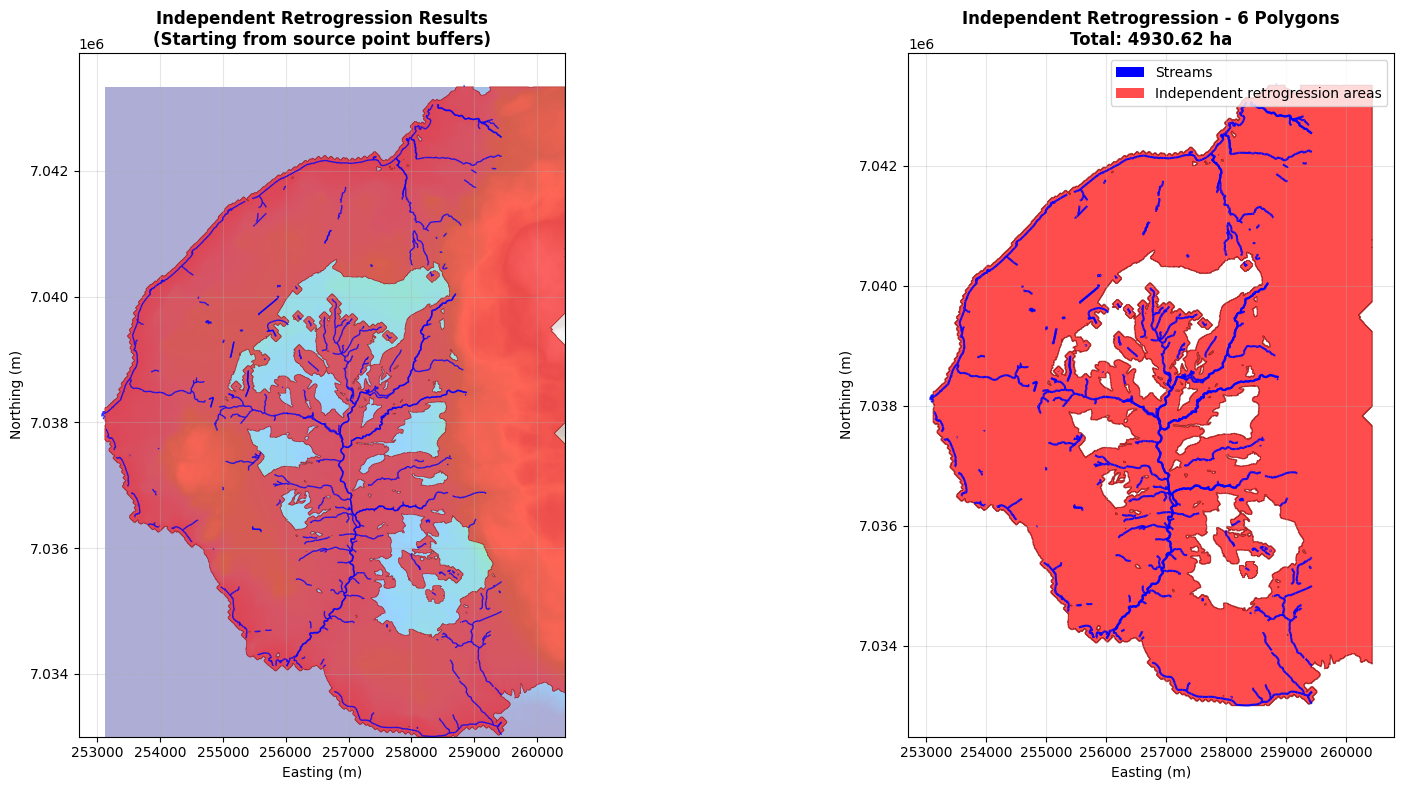

In [66]:
# Visualize independent retrogression results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Retrogression on DEM
ax1 = axes[0]
with rasterio.open(CUSTOM_DEM) as src:
    show(src, ax=ax1, cmap='terrain', alpha=0.4)
retro_result_independent.plot(ax=ax1, color='red', alpha=0.6, edgecolor='darkred', linewidth=0.5)
streams.plot(ax=ax1, color='blue', linewidth=1, alpha=0.8)
ax1.set_title('Independent Retrogression Results\n(Starting from source point buffers)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.grid(True, alpha=0.3)

# Plot 2: Close-up without DEM
ax2 = axes[1]
retro_result_independent.plot(ax=ax2, color='red', alpha=0.7, edgecolor='darkred', linewidth=0.8)
streams.plot(ax=ax2, color='blue', linewidth=1.5, alpha=0.9)
ax2.set_title(f'Independent Retrogression - {len(retro_result_independent)} Polygons\n'
              f'Total: {retro_result_independent.geometry.area.sum()/10000:.2f} ha', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='blue', label='Streams'),
    Patch(facecolor='red', alpha=0.7, label='Independent retrogression areas')
]
ax2.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

In [68]:
# Save independent retrogression results
retro_independent_output = f"{OUTPUT_DIR}/retrogression_independent.geojson"
retro_result_independent.to_file(retro_independent_output, driver='GeoJSON')

print(f"✓ Independent retrogression results saved to: {retro_independent_output}")

✓ Independent retrogression results saved to: ../output/retrogression_independent.geojson


---

### 10B. Retrogression from Terrain Criteria (Sequential/Combined Method)

This approach uses terrain criteria results as the initial release zones for retrogression:

In [67]:
print("Running SEQUENTIAL retrogression analysis...")
print("Starting from terrain criteria results")
print("This step-wise propagation may take several minutes...")
print("(Progress bar disabled - please wait...)\n")

retro_result_sequential = retrogression.run_retrogression(
    bounds=bounds,
    rel_shape=tc_result,  # Using terrain criteria results as initial release!
    point_depth=SOURCE_DEPTH,
    clip_to_msml=CLIP_TO_MSML,
    min_slope=MIN_SLOPE,
    min_height=MIN_HEIGHT,
    min_length=MIN_LENGTH,
    custom_raster=CUSTOM_DEM,
    return_animation=False,
    verbose=False  # Disabled to avoid ipywidgets requirement
)

print(f"\n✓ Sequential retrogression analysis completed!")
print(f"  Polygons: {len(retro_result_sequential)}")
print(f"  Total area: {retro_result_sequential.geometry.area.sum():.2f} m²")
print(f"  Total area: {retro_result_sequential.geometry.area.sum()/10000:.2f} hectares")
print(f"  Avg polygon area: {retro_result_sequential.geometry.area.mean():.2f} m²")
print(f"  Largest polygon: {retro_result_sequential.geometry.area.max():.2f} m²")

Running SEQUENTIAL retrogression analysis...
Starting from terrain criteria results
This step-wise propagation may take several minutes...
(Progress bar disabled - please wait...)



MemoryError: Unable to allocate 311. GiB for an array with shape (20363, 2052958) and data type float64

In [ ]:
# Visualize sequential retrogression
fig, ax = plt.subplots(figsize=(12, 10))

with rasterio.open(CUSTOM_DEM) as src:
    show(src, ax=ax, cmap='terrain', alpha=0.4)
    
# Show both terrain criteria (starting point) and retrogression (result)
tc_result.plot(ax=ax, color='orange', alpha=0.4, edgecolor='darkorange', linewidth=0.5, label='Terrain criteria (initial)')
retro_result_sequential.plot(ax=ax, color='purple', alpha=0.5, edgecolor='darkviolet', linewidth=0.5, label='Retrogression (expanded)')
streams.plot(ax=ax, color='blue', linewidth=1, alpha=0.8, label='Streams')

ax.set_title('Sequential Method: Retrogression from Terrain Criteria\n'
             f'TC: {tc_result.geometry.area.sum()/10000:.2f} ha → Retro: {retro_result_sequential.geometry.area.sum()/10000:.2f} ha', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Compare All Three Methods

Now we can compare:
1. **Terrain Criteria** - Direct slope analysis from source points
2. **Independent Retrogression** - Propagation from buffered source points
3. **Sequential Retrogression** - Propagation from terrain criteria results

In [ ]:
# Create comparison visualization for all three methods
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Terrain Criteria
ax1 = axes[0, 0]
tc_result.plot(ax=ax1, color='orange', alpha=0.6, edgecolor='darkorange', linewidth=0.5)
streams.plot(ax=ax1, color='blue', linewidth=1, alpha=0.8)
ax1.set_title(f'Method 1: Terrain Criteria\n{len(tc_result)} polygons, {tc_result.geometry.area.sum()/10000:.2f} ha', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.grid(True, alpha=0.3)

# Plot 2: Independent Retrogression
ax2 = axes[0, 1]
retro_result_independent.plot(ax=ax2, color='red', alpha=0.6, edgecolor='darkred', linewidth=0.5)
streams.plot(ax=ax2, color='blue', linewidth=1, alpha=0.8)
ax2.set_title(f'Method 2: Independent Retrogression\n{len(retro_result_independent)} polygons, {retro_result_independent.geometry.area.sum()/10000:.2f} ha', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.grid(True, alpha=0.3)

# Plot 3: Sequential Retrogression
ax3 = axes[1, 0]
retro_result_sequential.plot(ax=ax3, color='purple', alpha=0.6, edgecolor='darkviolet', linewidth=0.5)
streams.plot(ax=ax3, color='blue', linewidth=1, alpha=0.8)
ax3.set_title(f'Method 3: Sequential Retrogression\n{len(retro_result_sequential)} polygons, {retro_result_sequential.geometry.area.sum()/10000:.2f} ha', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Easting (m)')
ax3.set_ylabel('Northing (m)')
ax3.grid(True, alpha=0.3)

# Plot 4: All methods overlaid
ax4 = axes[1, 1]
tc_result.plot(ax=ax4, color='orange', alpha=0.3, edgecolor='darkorange', linewidth=0.5)
retro_result_independent.plot(ax=ax4, color='red', alpha=0.3, edgecolor='darkred', linewidth=0.5)
retro_result_sequential.plot(ax=ax4, color='purple', alpha=0.3, edgecolor='darkviolet', linewidth=0.5)
streams.plot(ax=ax4, color='blue', linewidth=1.5, alpha=0.9)
ax4.set_title('All Methods Combined', fontsize=12, fontweight='bold')
ax4.set_xlabel('Easting (m)')
ax4.set_ylabel('Northing (m)')
ax4.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='blue', label='Streams'),
    Patch(facecolor='orange', alpha=0.4, label='Terrain criteria'),
    Patch(facecolor='red', alpha=0.4, label='Independent retrogression'),
    Patch(facecolor='purple', alpha=0.4, label='Sequential retrogression')
]
ax4.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

In [ ]:
# Comparison statistics for all three methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot: Areas
ax1 = axes[0]
methods = ['Terrain\nCriteria', 'Independent\nRetrogression', 'Sequential\nRetrogression']
areas = [
    tc_result.geometry.area.sum()/10000, 
    retro_result_independent.geometry.area.sum()/10000,
    retro_result_sequential.geometry.area.sum()/10000
]
colors = ['orange', 'red', 'purple']
bars = ax1.bar(methods, areas, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Area (hectares)', fontsize=12, fontweight='bold')
ax1.set_title('Total Release Area Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, area in zip(bars, areas):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{area:.2f} ha', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Bar plot: Counts
ax2 = axes[1]
counts = [len(tc_result), len(retro_result_independent), len(retro_result_sequential)]
bars = ax2.bar(methods, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Polygons', fontsize=12, fontweight='bold')
ax2.set_title('Feature Count Comparison', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARISON SUMMARY - THREE METHODS")
print("="*70)
print(f"\n1. Terrain Criteria (direct slope analysis):")
print(f"   - Polygons: {len(tc_result)}")
print(f"   - Area: {areas[0]:.2f} ha")

print(f"\n2. Independent Retrogression (from source point buffers):")
print(f"   - Polygons: {len(retro_result_independent)}")
print(f"   - Area: {areas[1]:.2f} ha")
print(f"   - Difference from TC: {abs(areas[1]-areas[0]):.2f} ha ({abs(areas[1]-areas[0])/areas[0]*100:.1f}%)")

print(f"\n3. Sequential Retrogression (from terrain criteria):")
print(f"   - Polygons: {len(retro_result_sequential)}")
print(f"   - Area: {areas[2]:.2f} ha")
print(f"   - Difference from TC: {abs(areas[2]-areas[0]):.2f} ha ({abs(areas[2]-areas[0])/areas[0]*100:.1f}%)")

print("\n" + "="*70)

## 12. Save All Results

In [ ]:
# Save all results
retro_independent_output = f"{OUTPUT_DIR}/retrogression_independent.geojson"
retro_sequential_output = f"{OUTPUT_DIR}/retrogression_sequential.geojson"

retro_result_independent.to_file(retro_independent_output, driver='GeoJSON')
retro_result_sequential.to_file(retro_sequential_output, driver='GeoJSON')

print(f"✓ Results saved:")
print(f"  - Terrain criteria: {tc_output}")
print(f"  - Independent retrogression: {retro_independent_output}")
print(f"  - Sequential retrogression: {retro_sequential_output}")

## 13. Generate Summary Report

In [ ]:
from datetime import datetime

# Save summary file
summary_file = f"{OUTPUT_DIR}/analysis_summary_custom_dem.txt"
with open(summary_file, 'w') as f:
    f.write("RELEASE AREA ANALYSIS - THREE INDEPENDENT METHODS\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("INPUT DATA:\n")
    f.write(f"  - Streams: {STREAM_FILE}\n")
    f.write(f"  - DEM: {CUSTOM_DEM}\n")
    f.write(f"  - Stream features: {len(streams)}\n")
    f.write(f"  - Source points: {len(source_points):,}\n\n")
    
    f.write("PARAMETERS:\n")
    f.write(f"  - Source depth: {SOURCE_DEPTH} m\n")
    f.write(f"  - Minimum height: {MIN_HEIGHT} m\n")
    f.write(f"  - Minimum slope: 1:{int(1/MIN_SLOPE)} ({MIN_SLOPE:.4f})\n")
    f.write(f"  - Minimum length: {MIN_LENGTH} m\n")
    f.write(f"  - Buffer distance: {BUFFER_DISTANCE} m\n")
    f.write(f"  - Point spacing: {1/POINTS_PER_METER:.1f} m\n")
    f.write(f"  - MSML clipping: {CLIP_TO_MSML}\n")
    f.write(f"  - Initial buffer for retrogression: {INITIAL_BUFFER} m\n\n")
    
    f.write("RESULTS:\n")
    f.write(f"\n1. Terrain Criteria (direct slope analysis):\n")
    f.write(f"  - Polygons: {len(tc_result)}\n")
    f.write(f"  - Total area: {tc_result.geometry.area.sum():.2f} m²\n")
    f.write(f"  - Total area: {tc_result.geometry.area.sum()/10000:.2f} hectares\n")
    f.write(f"  - Average polygon: {tc_result.geometry.area.mean():.2f} m²\n")
    
    f.write(f"\n2. Independent Retrogression (from source point buffers):\n")
    f.write(f"  - Polygons: {len(retro_result_independent)}\n")
    f.write(f"  - Total area: {retro_result_independent.geometry.area.sum():.2f} m²\n")
    f.write(f"  - Total area: {retro_result_independent.geometry.area.sum()/10000:.2f} hectares\n")
    f.write(f"  - Average polygon: {retro_result_independent.geometry.area.mean():.2f} m²\n")
    
    f.write(f"\n3. Sequential Retrogression (from terrain criteria):\n")
    f.write(f"  - Polygons: {len(retro_result_sequential)}\n")
    f.write(f"  - Total area: {retro_result_sequential.geometry.area.sum():.2f} m²\n")
    f.write(f"  - Total area: {retro_result_sequential.geometry.area.sum()/10000:.2f} hectares\n")
    f.write(f"  - Average polygon: {retro_result_sequential.geometry.area.mean():.2f} m²\n")
    
    f.write(f"\nOUTPUT FILES:\n")
    f.write(f"  - {tc_output}\n")
    f.write(f"  - {retro_independent_output}\n")
    f.write(f"  - {retro_sequential_output}\n")

print(f"✓ Summary saved to: {summary_file}")

# Display summary
print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\n📊 RESULTS SUMMARY:")
print(f"\n1. Terrain Criteria:")
print(f"  - Polygons: {len(tc_result)}")
print(f"  - Area: {tc_result.geometry.area.sum()/10000:.2f} hectares")
print(f"\n2. Independent Retrogression:")
print(f"  - Polygons: {len(retro_result_independent)}")
print(f"  - Area: {retro_result_independent.geometry.area.sum()/10000:.2f} hectares")
print(f"\n3. Sequential Retrogression:")
print(f"  - Polygons: {len(retro_result_sequential)}")
print(f"  - Area: {retro_result_sequential.geometry.area.sum()/10000:.2f} hectares")
print(f"\n📁 OUTPUT FILES:")
print(f"  - {tc_output}")
print(f"  - {retro_independent_output}")
print(f"  - {retro_sequential_output}")
print(f"  - {summary_file}")

---

## Summary

This notebook demonstrates **three independent methods** for landslide release area analysis:

### Methods Implemented:

1. ✅ **Terrain Criteria** - Direct slope analysis from source points to all DEM pixels
   - Independent method using geometric calculations
   - Fast, conservative estimates
   
2. ✅ **Independent Retrogression** - Step-wise propagation from buffered source points
   - Independent method using iterative upslope expansion
   - Does NOT depend on terrain criteria results
   
3. ✅ **Sequential Retrogression** - Propagation from terrain criteria results
   - Combined workflow approach
   - Uses TC results as initial release zones

### Key Insights:

- **Terrain Criteria** and **Retrogression** are fundamentally different algorithms
- Both can be run independently from the same source data (streams/points)
- Sequential approach combines both methods for comprehensive analysis
- Results typically show: TC < Independent Retro ≈ Sequential Retro

### Next Steps:

- Compare all three methods in QGIS/ArcGIS
- Validate against field observations
- Choose appropriate method based on project requirements
- Adjust parameters in Section 2 and re-run if needed

### References:

- NVE Veileder 1/2019: https://publikasjoner.nve.no/veileder/2019/veileder2019_01.pdf
- Package repository: https://github.com/cgodoyle/losneomrade